 =============================================================================
# ANALYSE DES VENTES RETAIL - superstore
 =============================================================================

## Imports

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

## Style global

In [4]:
# ── Style global ──────────────────────────────────────────────────────────────────

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

OUTPUT_DIR = "outputs"
POWERBI_DIR = "powerbi_exports"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(POWERBI_DIR, exist_ok=True)

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
GRAY   = "#888780"
RED    = "#E24B4A"
GREEN  = "#639922"



 =============================================================================
# SECTION 1 — CHARGEMENT & APERÇU
 =============================================================================

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ── Chargement ────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("/content/drive/MyDrive/Projets Data/Chaîne de distribution US/superstore.csv", encoding="latin1")
df = df_raw.copy() # on conserve df_raw intact pour comparaison finale

# ── Aperçu ────────────────────────────────────────────────────────────────

print(f"\nDimensions brutes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print("\nColonnes et types bruts :")
print(df.dtypes.to_string())

print("\nAperçu des 5 premières lignes :")
print(df.head(5).to_string())

print("\nAperçu des 5 dernières lignes :")
print(df.tail(5).to_string())


Dimensions brutes : 9,994 lignes × 21 colonnes

Colonnes et types bruts :
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64

Aperçu des 5 premières lignes :
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID    Customer Name    Segment        Country             City       State  Postal Code Region       Product ID         Category Sub-Category                                                 Product Name     Sales  Quantity  Discount    Profit
0       1  CA-2016-152156   11/8/2016  11/11/2016

=============================================================================
# SECTION 2 — DATA QUALITY (NaN · DOUBLONS · TYPES)
=============================================================================

## Valeurs manquantes

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "Nb NaN"     : missing,
    "% NaN"      : missing_pct,
    "Type"       : df.dtypes,
    "Nb distincts": df.nunique(),
}).sort_values("Nb NaN", ascending=False)

print(missing_report.to_string())

cols_with_nan = missing[missing > 0]
if cols_with_nan.empty:
    print("\n  ✓ Aucune valeur manquante détectée dans le dataset brut.")
else:
    print(f"\n  ✗ {len(cols_with_nan)} colonne(s) avec NaN — traitement en section 4.")

               Nb NaN  % NaN     Type  Nb distincts
Row ID              0    0.0    int64          9994
Order ID            0    0.0   object          5009
Order Date          0    0.0   object          1237
Ship Date           0    0.0   object          1334
Ship Mode           0    0.0   object             4
Customer ID         0    0.0   object           793
Customer Name       0    0.0   object           793
Segment             0    0.0   object             3
Country             0    0.0   object             1
City                0    0.0   object           531
State               0    0.0   object            49
Postal Code         0    0.0    int64           631
Region              0    0.0   object             4
Product ID          0    0.0   object          1862
Category            0    0.0   object             3
Sub-Category        0    0.0   object            17
Product Name        0    0.0   object          1850
Sales               0    0.0  float64          5825
Quantity    

## Doublons

In [8]:
n_dup_rows = df.duplicated().sum()
print(f"  Lignes entièrement dupliquées   : {n_dup_rows:,}")

# Doublons sur la clé métier (Order ID + Product ID = une ligne de commande)
n_dup_key = df.duplicated(subset=["Order ID", "Product ID"]).sum()
print(f"  Doublons sur (Order ID, Product ID) : {n_dup_key:,}")

if n_dup_rows > 0:
    print("\n  Aperçu des lignes dupliquées :")
    print(df[df.duplicated(keep=False)].head(6).to_string())

  Lignes entièrement dupliquées   : 0
  Doublons sur (Order ID, Product ID) : 8


## Cohérence des dates

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=False, errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=False, errors="coerce")

date_parse_errors = df["Order Date"].isna().sum() + df["Ship Date"].isna().sum()
print(f"  Erreurs de parsing dates : {date_parse_errors}")

incoherent_dates = (df["Ship Date"] < df["Order Date"]).sum()
print(f"  Lignes où Ship Date < Order Date : {incoherent_dates}")

  Erreurs de parsing dates : 0
  Lignes où Ship Date < Order Date : 0


## Cohérence des métriques financières


In [10]:
neg_sales    = (df["Sales"]    <= 0).sum()
zero_qty     = (df["Quantity"] <= 0).sum()
discount_ko  = ((df["Discount"] < 0) | (df["Discount"] > 1)).sum()

print(f"  Sales <= 0         : {neg_sales:,} lignes")
print(f"  Quantity <= 0      : {zero_qty:,} lignes")
print(f"  Discount hors [0,1]: {discount_ko:,} lignes")
print(f"  Profit < 0         : {(df['Profit'] < 0).sum():,} lignes  "
      f"(attendu — remises élevées)")

  Sales <= 0         : 0 lignes
  Quantity <= 0      : 0 lignes
  Discount hors [0,1]: 0 lignes
  Profit < 0         : 1,871 lignes  (attendu — remises élevées)


## Standardisation des chaînes

In [11]:
print("\n── 2.5 Valeurs aberrantes dans les colonnes catégorielles ──")
cat_cols = ["Ship Mode", "Segment", "Country", "Region", "Category", "Sub-Category"]
for col in cat_cols:
    vals = df[col].unique()
    print(f"  {col:<20} ({len(vals)} valeurs) : {sorted(vals)}")


── 2.5 Valeurs aberrantes dans les colonnes catégorielles ──
  Ship Mode            (4 valeurs) : ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Segment              (3 valeurs) : ['Consumer', 'Corporate', 'Home Office']
  Country              (1 valeurs) : ['United States']
  Region               (4 valeurs) : ['Central', 'East', 'South', 'West']
  Category             (3 valeurs) : ['Furniture', 'Office Supplies', 'Technology']
  Sub-Category         (17 valeurs) : ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']


=============================================================================
# SECTION 3 — DÉTECTION & TRAITEMENT DES OUTLIERS
=============================================================================


In [12]:
# ── colonnes numériques ────────────────────────────────────────────────────────────────

numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

## Statistiques descriptives étendues

In [13]:
desc = df[numeric_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
print(desc.round(2).to_string())

          Sales  Quantity  Discount   Profit
count   9994.00   9994.00   9994.00  9994.00
mean     229.86      3.79      0.16    28.66
std      623.25      2.23      0.21   234.26
min        0.44      1.00      0.00 -6599.98
1%         2.29      1.00      0.00  -319.26
5%         4.98      1.00      0.00   -53.03
25%       17.28      2.00      0.00     1.73
50%       54.49      3.00      0.20     8.67
75%      209.94      5.00      0.20    29.36
95%      956.98      8.00      0.70   168.47
99%     2481.69     11.00      0.80   580.66
max    22638.48     14.00      0.80  8399.98


## Méthode IQR — détection des outliers

In [14]:
outlier_summary = []
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR   # borne basse
    ub  = Q3 + 1.5 * IQR   # borne haute

    n_low  = (df[col] < lb).sum()
    n_high = (df[col] > ub).sum()
    n_tot  = n_low + n_high
    pct    = n_tot / len(df) * 100

    outlier_summary.append({
        "Colonne"      : col,
        "Q1"           : round(Q1, 2),
        "Q3"           : round(Q3, 2),
        "IQR"          : round(IQR, 2),
        "Borne basse"  : round(lb, 2),
        "Borne haute"  : round(ub, 2),
        "N outliers <" : n_low,
        "N outliers >"  : n_high,
        "Total"        : n_tot,
        "% dataset"    : round(pct, 2),
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

 Colonne    Q1     Q3    IQR  Borne basse  Borne haute  N outliers <  N outliers >  Total  % dataset
   Sales 17.28 209.94 192.66      -271.71       498.93             0          1167   1167      11.68
Quantity  2.00   5.00   3.00        -2.50         9.50             0           170    170       1.70
Discount  0.00   0.20   0.20        -0.30         0.50             0           856    856       8.57
  Profit  1.73  29.36  27.64       -39.72        70.82           604          1277   1881      18.82


## Méthode Z-score — confirmation

In [15]:
for col in numeric_cols:
    z      = (df[col] - df[col].mean()) / df[col].std()
    n_zsco = (z.abs() > 3).sum()
    print(f"  {col:<12} : {n_zsco:,} outliers (|z| > 3)")

  Sales        : 127 outliers (|z| > 3)
  Quantity     : 113 outliers (|z| > 3)
  Discount     : 300 outliers (|z| > 3)
  Profit       : 107 outliers (|z| > 3)


## Visualisation des distributions

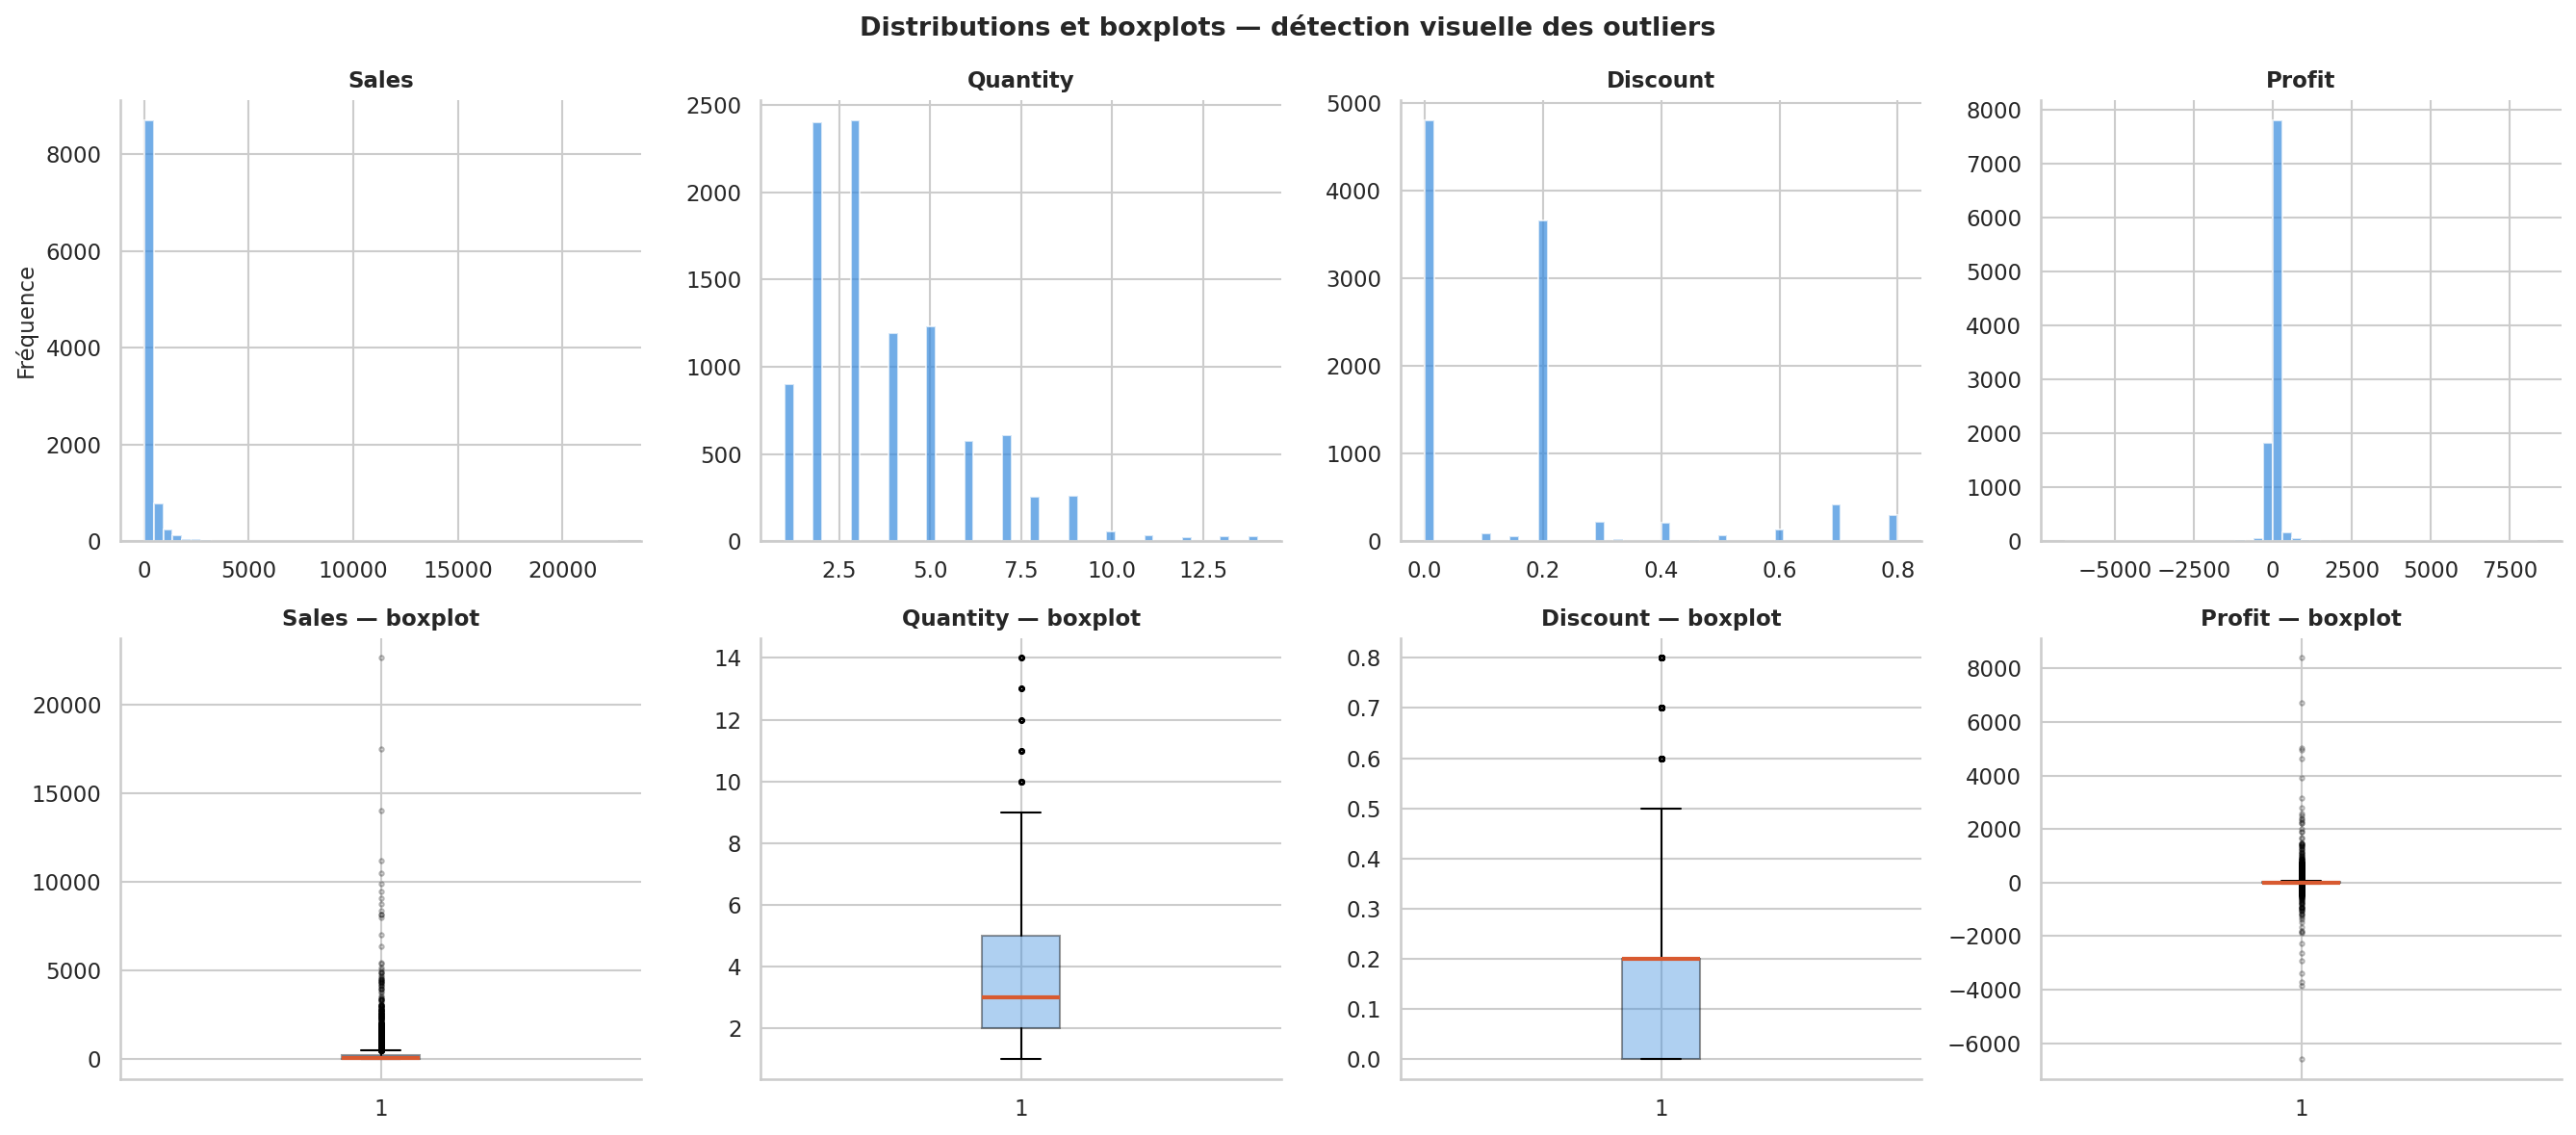


  → Graphique sauvegardé : 01_distributions_outliers.png


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distributions et boxplots — détection visuelle des outliers",
             fontsize=13, fontweight="bold")

for i, col in enumerate(numeric_cols):
    # Histogramme
    ax_hist = axes[0, i]
    ax_hist.hist(df[col].dropna(), bins=50, color=BLUE, alpha=0.7, edgecolor="white")
    ax_hist.set_title(col, fontsize=11)
    ax_hist.set_ylabel("Fréquence" if i == 0 else "")

    # Boxplot
    ax_box = axes[1, i]
    ax_box.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor=BLUE, alpha=0.4),
                   medianprops=dict(color=CORAL, linewidth=2),
                   flierprops=dict(marker=".", color=RED, alpha=0.3, markersize=4))
    ax_box.set_title(f"{col} — boxplot", fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_distributions_outliers.png", bbox_inches="tight")
plt.show()
print("\n  → Graphique sauvegardé : 01_distributions_outliers.png")

## Analyse détaillée des outliers Sales

In [17]:
Q1_s, Q3_s = df["Sales"].quantile([0.25, 0.75])
ub_sales    = Q3_s + 1.5 * (Q3_s - Q1_s)

sales_outliers = df[df["Sales"] > ub_sales][
    ["Order ID", "Category", "Sub-Category", "Product Name",
     "Sales", "Quantity", "Discount", "Profit"]
].sort_values("Sales", ascending=False)

print(f"  Seuil IQR haut pour Sales : ${ub_sales:,.2f}")
print(f"  Nombre de lignes concernées : {len(sales_outliers):,}")
print("\n  Top 10 commandes en valeur :")
print(sales_outliers.head(10).to_string(index=False))

  Seuil IQR haut pour Sales : $498.93
  Nombre de lignes concernées : 1,167

  Top 10 commandes en valeur :
      Order ID        Category Sub-Category                                              Product Name     Sales  Quantity  Discount     Profit
CA-2014-145317      Technology     Machines     Cisco TelePresence System EX90 Videoconferencing Unit 22638.480         6       0.5 -1811.0784
CA-2016-118689      Technology      Copiers                     Canon imageCLASS 2200 Advanced Copier 17499.950         5       0.0  8399.9760
CA-2017-140151      Technology      Copiers                     Canon imageCLASS 2200 Advanced Copier 13999.960         4       0.0  6719.9808
CA-2017-127180      Technology      Copiers                     Canon imageCLASS 2200 Advanced Copier 11199.968         4       0.2  3919.9888
CA-2017-166709      Technology      Copiers                     Canon imageCLASS 2200 Advanced Copier 10499.970         3       0.0  5039.9856
CA-2016-117121 Office Supplies    

## Analyse détaillée des outliers Profit

In [18]:
Q1_p, Q3_p = df["Profit"].quantile([0.25, 0.75])
lb_profit   = Q1_p - 1.5 * (Q3_p - Q1_p)
ub_profit   = Q3_p + 1.5 * (Q3_p - Q1_p)

profit_out_low  = df[df["Profit"] < lb_profit]
profit_out_high = df[df["Profit"] > ub_profit]

print(f"  Borne basse Profit : ${lb_profit:,.2f}")
print(f"  Borne haute Profit : ${ub_profit:,.2f}")
print(f"  Pertes extrêmes (< borne basse) : {len(profit_out_low):,} lignes")
print(f"  Profits extrêmes (> borne haute): {len(profit_out_high):,} lignes")

print("\n  Top 5 pertes extrêmes :")
print(profit_out_low.nsmallest(5, "Profit")[
    ["Order ID","Category","Sub-Category","Sales","Discount","Profit"]
].to_string(index=False))

print("\n  Top 5 profits extrêmes :")
print(profit_out_high.nlargest(5, "Profit")[
    ["Order ID","Category","Sub-Category","Sales","Discount","Profit"]
].to_string(index=False))

  Borne basse Profit : $-39.72
  Borne haute Profit : $70.82
  Pertes extrêmes (< borne basse) : 604 lignes
  Profits extrêmes (> borne haute): 1,277 lignes

  Top 5 pertes extrêmes :
      Order ID        Category Sub-Category    Sales  Discount     Profit
CA-2016-108196      Technology     Machines 4499.985       0.7 -6599.9780
US-2017-168116      Technology     Machines 7999.980       0.5 -3839.9904
CA-2014-169019 Office Supplies      Binders 2177.584       0.8 -3701.8928
CA-2017-134845      Technology     Machines 2549.985       0.7 -3399.9800
US-2017-122714 Office Supplies      Binders 1889.990       0.8 -2929.4845

  Top 5 profits extrêmes :
      Order ID        Category Sub-Category    Sales  Discount    Profit
CA-2016-118689      Technology      Copiers 17499.95       0.0 8399.9760
CA-2017-140151      Technology      Copiers 13999.96       0.0 6719.9808
CA-2017-166709      Technology      Copiers 10499.97       0.0 5039.9856
CA-2016-117121 Office Supplies      Binders  9892.74

## Décision traitement des outliers

In [19]:
print("""

  Sales outliers   → CONSERVER
    Justification : les grandes commandes (matériel IT, mobilier de bureau)
    sont des cas légitimes dans un contexte B2B/B2C retail.
    Les supprimer biaiserait l'analyse du CA réel.

  Profit outliers  → CONSERVER + SIGNALER
    Justification : les pertes extrêmes sont réelles et directement liées
    aux remises >40%. Ce sont des insights business, pas des erreurs.
    On crée un flag 'Is_Extreme_Loss' pour les isoler dans Power BI.

  Profit < 0       → CONSERVER (attendu métier)
    Ces lignes représentent ~30% du dataset et sont au cœur de l'analyse
    remises/marge. Les supprimer viderait l'analyse de son sens.
""")



  Sales outliers   → CONSERVER
    Justification : les grandes commandes (matériel IT, mobilier de bureau)
    sont des cas légitimes dans un contexte B2B/B2C retail.
    Les supprimer biaiserait l'analyse du CA réel.

  Profit outliers  → CONSERVER + SIGNALER
    Justification : les pertes extrêmes sont réelles et directement liées
    aux remises >40%. Ce sont des insights business, pas des erreurs.
    On crée un flag 'Is_Extreme_Loss' pour les isoler dans Power BI.

  Profit < 0       → CONSERVER (attendu métier)
    Ces lignes représentent ~30% du dataset et sont au cœur de l'analyse
    remises/marge. Les supprimer viderait l'analyse de son sens.



=============================================================================
# SECTION 4 — NETTOYAGE & STANDARDISATION
=============================================================================

In [20]:
n_avant = len(df)

# Suppression des doublons exacts

In [21]:
df = df.drop_duplicates()
print(f"  Lignes supprimées : {n_avant - len(df):,}  "
      f"(restantes : {len(df):,})")

  Lignes supprimées : 0  (restantes : 9,994)


# Lignes incohérentes (dates + métriques)

In [22]:
print("\n── 4.2 Suppression des lignes incohérentes ──")
n_before = len(df)

mask_date_ko  = df["Ship Date"] < df["Order Date"]
mask_sales_ko = df["Sales"] <= 0
mask_qty_ko   = df["Quantity"] <= 0
mask_disc_ko  = (df["Discount"] < 0) | (df["Discount"] > 1)

mask_drop = mask_date_ko | mask_sales_ko | mask_qty_ko | mask_disc_ko

print(f"  Date incohérente (Ship < Order) : {mask_date_ko.sum():,}")
print(f"  Sales <= 0                       : {mask_sales_ko.sum():,}")
print(f"  Quantity <= 0                    : {mask_qty_ko.sum():,}")
print(f"  Discount hors [0, 1]             : {mask_disc_ko.sum():,}")
print(f"  Total lignes supprimées          : {mask_drop.sum():,}")

df = df[~mask_drop].copy()
print(f"  Lignes restantes après nettoyage : {len(df):,}")


── 4.2 Suppression des lignes incohérentes ──
  Date incohérente (Ship < Order) : 0
  Sales <= 0                       : 0
  Quantity <= 0                    : 0
  Discount hors [0, 1]             : 0
  Total lignes supprimées          : 0
  Lignes restantes après nettoyage : 9,994


# Standardisation des chaînes

In [23]:
# ── Standardisation ──────────────────────────────────────────────────────
str_cols = df.select_dtypes(include="object").columns.tolist()
for col in str_cols:
    df[col] = df[col].str.strip()
print(f"  Strip appliqué sur {len(str_cols)} colonnes texte : {str_cols}")

# ── Types définitifs ──────────────────────────────────────────────────────
print("\n── 4.4 Types de colonnes après nettoyage ──")
print(df.dtypes.to_string())


  Strip appliqué sur 13 colonnes texte : ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']

── 4.4 Types de colonnes après nettoyage ──
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64


## Vérification finale NaN

In [24]:
remaining_nan = df.isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0]
if remaining_nan.empty:
    print("  ✓ Aucune valeur manquante.")
else:
    print(remaining_nan.to_string())

  ✓ Aucune valeur manquante.


=============================================================================
# SECTION 5 — FEATURE ENGINEERING
=============================================================================

## Colonnes temporelles

In [25]:
df["Year"]        = df["Order Date"].dt.year
df["Month"]       = df["Order Date"].dt.month
df["Month_Name"]  = df["Order Date"].dt.strftime("%b")
df["Month_Name_Full"] = df["Order Date"].dt.strftime("%B")
df["YearMonth"]   = df["Order Date"].dt.to_period("M").astype(str)
df["Quarter"]     = "Q" + df["Order Date"].dt.quarter.astype(str)
df["YearQuarter"] = df["Year"].astype(str) + "-" + df["Quarter"]
df["DayOfWeek"]   = df["Order Date"].dt.day_name()
df["IsWeekend"]   = df["Order Date"].dt.dayofweek >= 5
df["Delivery_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("  Ajoutées : Year, Month, Month_Name, Month_Name_Full, YearMonth,")
print("             Quarter, YearQuarter, DayOfWeek, IsWeekend, Delivery_Days")

  Ajoutées : Year, Month, Month_Name, Month_Name_Full, YearMonth,
             Quarter, YearQuarter, DayOfWeek, IsWeekend, Delivery_Days


## Métriques financières

In [26]:
# Profit_Margin : gérer la division par zéro (Sales = 0 écarté en section 4)
df["Profit_Margin"]       = (df["Profit"] / df["Sales"]).round(4)
df["Revenue_Per_Unit"]    = (df["Sales"]  / df["Quantity"]).round(2)
df["Profit_Per_Unit"]     = (df["Profit"] / df["Quantity"]).round(2)

# Marge brute estimée (Sales - Profit = coûts approximatifs)
df["Estimated_Cost"]      = (df["Sales"] - df["Profit"]).round(2)

print("  Ajoutées : Profit_Margin, Revenue_Per_Unit, Profit_Per_Unit, Estimated_Cost")

  Ajoutées : Profit_Margin, Revenue_Per_Unit, Profit_Per_Unit, Estimated_Cost


## Segmentation des remises

In [27]:
bins   = [-0.001, 0.001, 0.20, 0.40, 1.0]
labels = ["Aucune (0%)", "Faible (1-20%)", "Moderee (21-40%)", "Forte (>40%)"]
df["Discount_Band"]       = pd.cut(df["Discount"], bins=bins, labels=labels)
df["Discount_Band_Order"] = pd.cut(df["Discount"], bins=bins,
                                   labels=[1, 2, 3, 4]).astype(float).astype("Int64")

print("  Ajoutées : Discount_Band, Discount_Band_Order")
print("  Répartition :")
print(df["Discount_Band"].value_counts().sort_index().to_string())

  Ajoutées : Discount_Band, Discount_Band_Order
  Répartition :
Discount_Band
Aucune (0%)         4798
Faible (1-20%)      3803
Moderee (21-40%)     460
Forte (>40%)         933


## Flags qualité & segmentation

In [28]:
df["Is_Profitable"]   = df["Profit"] > 0

# Pertes extrêmes : profit < percentile 1%
p1_profit             = df["Profit"].quantile(0.01)
df["Is_Extreme_Loss"] = df["Profit"] < p1_profit

# Commandes à fort CA (> percentile 95% — utile pour segmentation VIP)
p95_sales             = df["Sales"].quantile(0.95)
df["Is_High_Value"]   = df["Sales"] > p95_sales

# Livraison rapide vs lente (médiane comme seuil)
med_delivery          = df["Delivery_Days"].median()
df["Delivery_Speed"]  = np.where(df["Delivery_Days"] <= med_delivery,
                                 "Rapide", "Lente")

print(f"  Is_Profitable   : {df['Is_Profitable'].sum():,} commandes rentables "
      f"({df['Is_Profitable'].mean():.1%})")
print(f"  Is_Extreme_Loss : {df['Is_Extreme_Loss'].sum():,} pertes extrêmes "
      f"(profit < ${p1_profit:.0f})")
print(f"  Is_High_Value   : {df['Is_High_Value'].sum():,} commandes à fort CA "
      f"(sales > ${p95_sales:.0f})")
print(f"  Delivery_Speed  : seuil médiane = {med_delivery:.0f} jours")


  Is_Profitable   : 8,058 commandes rentables (80.6%)
  Is_Extreme_Loss : 100 pertes extrêmes (profit < $-319)
  Is_High_Value   : 500 commandes à fort CA (sales > $957)
  Delivery_Speed  : seuil médiane = 4 jours


## Conclusion Feature Engineering

In [29]:
print("\nListe complète des colonnes après feature engineering :")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


Liste complète des colonnes après feature engineering :
   1. Row ID
   2. Order ID
   3. Order Date
   4. Ship Date
   5. Ship Mode
   6. Customer ID
   7. Customer Name
   8. Segment
   9. Country
  10. City
  11. State
  12. Postal Code
  13. Region
  14. Product ID
  15. Category
  16. Sub-Category
  17. Product Name
  18. Sales
  19. Quantity
  20. Discount
  21. Profit
  22. Year
  23. Month
  24. Month_Name
  25. Month_Name_Full
  26. YearMonth
  27. Quarter
  28. YearQuarter
  29. DayOfWeek
  30. IsWeekend
  31. Delivery_Days
  32. Profit_Margin
  33. Revenue_Per_Unit
  34. Profit_Per_Unit
  35. Estimated_Cost
  36. Discount_Band
  37. Discount_Band_Order
  38. Is_Profitable
  39. Is_Extreme_Loss
  40. Is_High_Value
  41. Delivery_Speed


=============================================================================
# SECTION 6 — RAPPORT QUALITÉ FINAL
=============================================================================

In [30]:
n_apres     = len(df)
n_supprime  = n_avant - n_apres
pct_supprime = n_supprime / n_avant * 100

print(f"""
  ┌──────────────────────────────────────────────────────┐
  │              BILAN PRÉ-PROCESSING                    │
  ├──────────────────────────────────────────────────────┤
  │  Lignes brutes                  : {n_avant:>8,}           │
  │  Lignes supprimées              : {n_supprime:>8,}           │
  │  Taux de suppression            : {pct_supprime:>7.2f}%          │
  │  Lignes propres (dataset final) : {n_apres:>8,}           │
  ├──────────────────────────────────────────────────────┤
  │  Valeurs manquantes restantes   : {df.isnull().sum().sum():>8,}           │
  │  Doublons restants              : {df.duplicated().sum():>8,}           │
  │  Colonnes brutes                : {df_raw.shape[1]:>8,}           │
  │  Colonnes après engineering     : {df.shape[1]:>8,}           │
  └──────────────────────────────────────────────────────┘
""")


  ┌──────────────────────────────────────────────────────┐
  │              BILAN PRÉ-PROCESSING                    │
  ├──────────────────────────────────────────────────────┤
  │  Lignes brutes                  :    9,994           │
  │  Lignes supprimées              :        0           │
  │  Taux de suppression            :    0.00%          │
  │  Lignes propres (dataset final) :    9,994           │
  ├──────────────────────────────────────────────────────┤
  │  Valeurs manquantes restantes   :        0           │
  │  Doublons restants              :        0           │
  │  Colonnes brutes                :       21           │
  │  Colonnes après engineering     :       41           │
  └──────────────────────────────────────────────────────┘



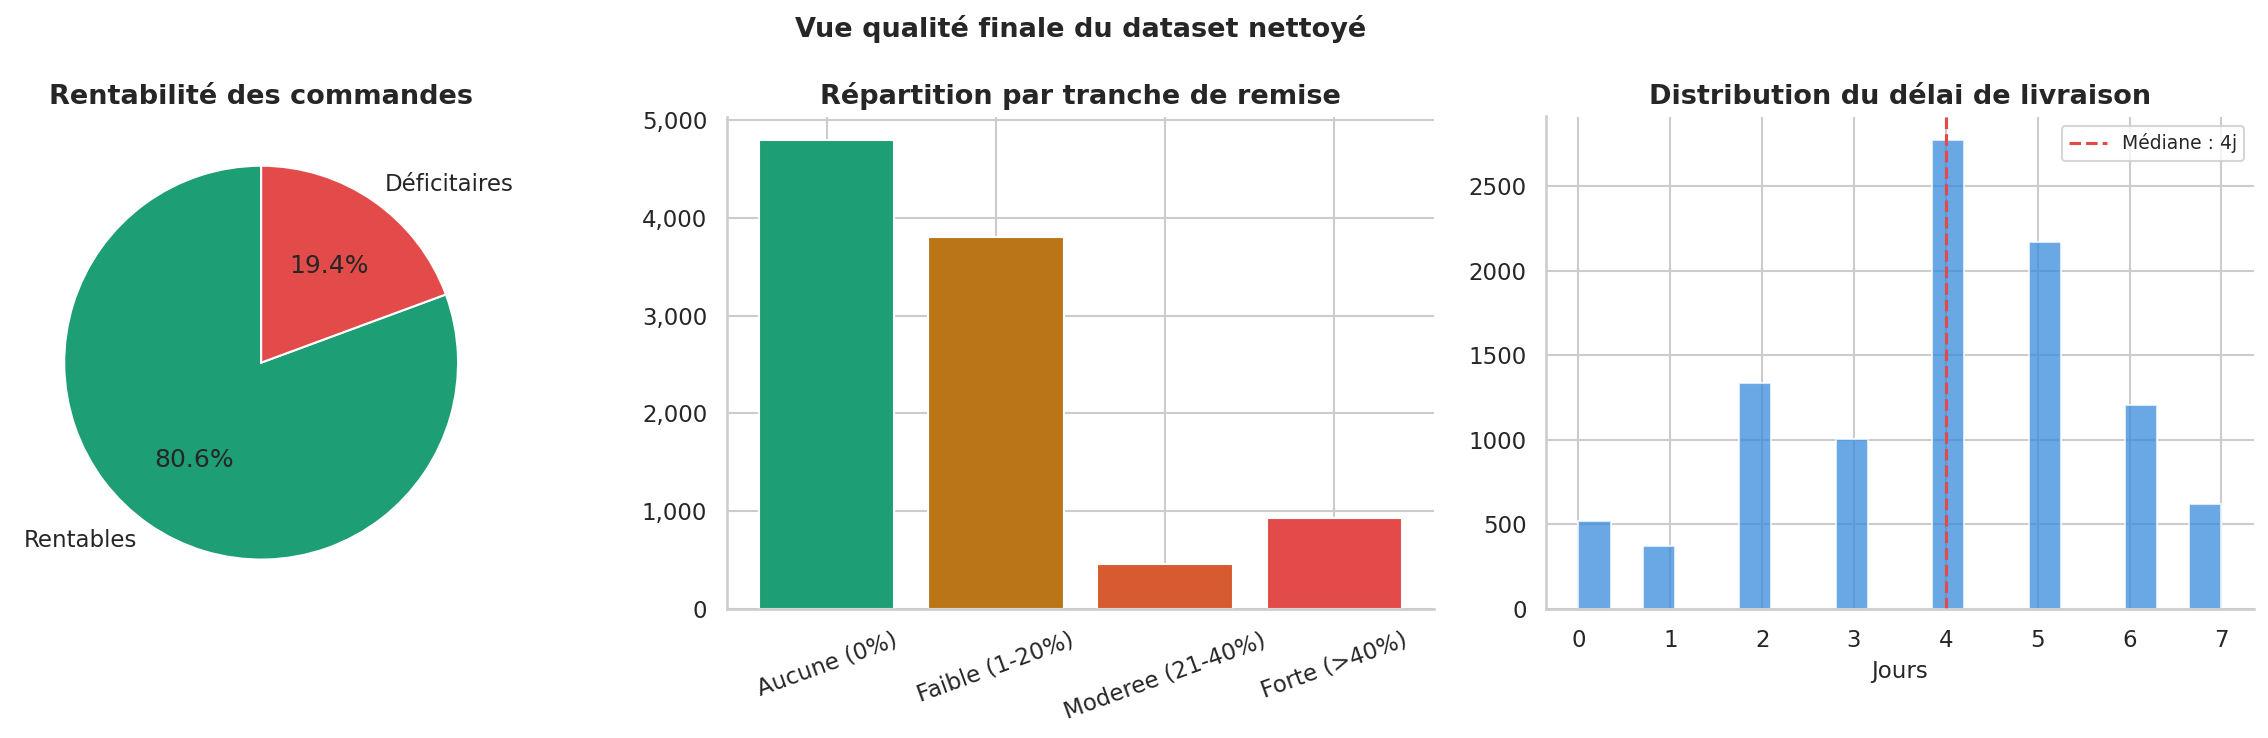

  → Graphique sauvegardé : 02_qualite_finale.png


In [31]:
# ── 6.1 Visualisation — vue d'ensemble qualité ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vue qualité finale du dataset nettoyé", fontsize=13, fontweight="bold")

# Répartition commandes rentables vs déficitaires
profitability = df["Is_Profitable"].value_counts()
axes[0].pie(
    profitability.values,
    labels=["Rentables", "Déficitaires"],
    colors=[TEAL, RED],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Rentabilité des commandes")

# Répartition par tranche de remise
discount_counts = df["Discount_Band"].value_counts().sort_index()
bar_colors_d = [TEAL, AMBER, CORAL, RED]
axes[1].bar(discount_counts.index, discount_counts.values, color=bar_colors_d)
axes[1].set_title("Répartition par tranche de remise")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Distribution du délai de livraison
axes[2].hist(df["Delivery_Days"].dropna(), bins=20, color=BLUE, alpha=0.75, edgecolor="white")
axes[2].axvline(df["Delivery_Days"].median(), color=RED, linestyle="--",
                linewidth=1.5, label=f"Médiane : {df['Delivery_Days'].median():.0f}j")
axes[2].set_title("Distribution du délai de livraison")
axes[2].set_xlabel("Jours")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_qualite_finale.png", bbox_inches="tight")
plt.show()
print("  → Graphique sauvegardé : 02_qualite_finale.png")

In [32]:
# ── 6.2 Statistiques descriptives finales ────────────────────────────────────
print("\n── 6.2 Statistiques finales (métriques clés) ──")
final_stats = df[["Sales","Quantity","Discount","Profit","Profit_Margin","Delivery_Days"]].describe(
    percentiles=[.25, .50, .75, .95]
).round(3)
print(final_stats.to_string())


── 6.2 Statistiques finales (métriques clés) ──
           Sales  Quantity  Discount    Profit  Profit_Margin  Delivery_Days
count   9994.000  9994.000  9994.000  9994.000       9994.000       9994.000
mean     229.858     3.790     0.156    28.657          0.120          3.958
std      623.245     2.225     0.206   234.260          0.467          1.748
min        0.444     1.000     0.000 -6599.978         -2.750          0.000
25%       17.280     2.000     0.000     1.729          0.075          3.000
50%       54.490     3.000     0.200     8.666          0.270          4.000
75%      209.940     5.000     0.200    29.364          0.362          5.000
95%      956.984     8.000     0.700   168.470          0.480          7.000
max    22638.480    14.000     0.800  8399.976          0.500          7.000


=============================================================================
# SECTION 7 — EXPORT CSV POUR POWER BI
=============================================================================

In [33]:
# ── 7.1 Table principale (flat) ───────────────────────────────────────────────
# Ordre des colonnes pensé pour Power Query :
# identifiants → dates → géo → client → produit → métriques → flags

export_cols = [
    # Identifiants
    "Row ID", "Order ID",

    # Dates brutes + colonnes calculées (pour dim_date dans Power Query)
    "Order Date", "Ship Date",
    "Year", "Quarter", "Month", "Month_Name", "Month_Name_Full",
    "YearMonth", "YearQuarter", "DayOfWeek", "IsWeekend",
    "Delivery_Days", "Delivery_Speed",

    # Mode de livraison
    "Ship Mode",

    # Client (pour dim_customer dans Power Query)
    "Customer ID", "Customer Name", "Segment",

    # Géographie (pour dim_geography dans Power Query)
    "Country", "City", "State", "Postal Code", "Region",

    # Produit (pour dim_product dans Power Query)
    "Product ID", "Product Name", "Category", "Sub-Category",

    # Métriques brutes
    "Sales", "Quantity", "Discount", "Profit",

    # Métriques calculées
    "Profit_Margin", "Revenue_Per_Unit", "Profit_Per_Unit", "Estimated_Cost",

    # Segmentation remises
    "Discount_Band", "Discount_Band_Order",

    # Flags qualité & segmentation
    "Is_Profitable", "Is_Extreme_Loss", "Is_High_Value",
]

# Vérification : toutes les colonnes existent
missing_cols = [c for c in export_cols if c not in df.columns]
if missing_cols:
    print(f"  ⚠ Colonnes absentes du DataFrame : {missing_cols}")
    export_cols = [c for c in export_cols if c in df.columns]

df_export = df[export_cols].copy()

# Formatage des dates en string ISO pour éviter les problèmes d'import Power BI
df_export["Order Date"] = df_export["Order Date"].dt.strftime("%Y-%m-%d")
df_export["Ship Date"]  = df_export["Ship Date"].dt.strftime("%Y-%m-%d")

# Conversion des booléens en 0/1 (plus robuste dans Power BI)
bool_cols = ["IsWeekend", "Is_Profitable", "Is_Extreme_Loss", "Is_High_Value"]
for col in bool_cols:
    if col in df_export.columns:
        df_export[col] = df_export[col].astype(int)


In [36]:
# Export
export_path = f"/content/drive/MyDrive/Projets Data/superstore_clean.csv"
df_export.to_csv(export_path, index=False, encoding="utf-8-sig")
# utf-8-sig : BOM inclus → Power BI lit les accents correctement

print(f"  ✓ superstore_clean.csv exporté")
print(f"    Chemin    : {export_path}")
print(f"    Lignes    : {len(df_export):,}")
print(f"    Colonnes  : {len(df_export.columns)}")
print(f"    Encodage  : UTF-8 avec BOM (utf-8-sig)")

# ── 7.2 Aperçu de l'export ───────────────────────────────────────────────────
print("\n  Aperçu des 3 premières lignes exportées :")
print(df_export.head(3).to_string())

print("\n  Colonnes exportées (dans l'ordre) :")
for i, col in enumerate(df_export.columns, 1):
    dtype = str(df_export[col].dtype)
    print(f"  {i:>2}. {col:<30} [{dtype}]")

  ✓ superstore_clean.csv exporté
    Chemin    : /content/drive/MyDrive/Projets Data/superstore_clean.csv
    Lignes    : 9,994
    Colonnes  : 41
    Encodage  : UTF-8 avec BOM (utf-8-sig)

  Aperçu des 3 premières lignes exportées :
   Row ID        Order ID  Order Date   Ship Date  Year Quarter  Month Month_Name Month_Name_Full YearMonth YearQuarter DayOfWeek  IsWeekend  Delivery_Days Delivery_Speed     Ship Mode Customer ID    Customer Name    Segment        Country         City       State  Postal Code Region       Product ID                                                 Product Name         Category Sub-Category   Sales  Quantity  Discount    Profit  Profit_Margin  Revenue_Per_Unit  Profit_Per_Unit  Estimated_Cost Discount_Band  Discount_Band_Order  Is_Profitable  Is_Extreme_Loss  Is_High_Value
0       1  CA-2016-152156  2016-11-08  2016-11-11  2016      Q4     11        Nov        November   2016-11     2016-Q4   Tuesday          0              3         Rapide  Second Class  